In [27]:
import time 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tflite_runtime.interpreter as tflite

from picamera2 import Picamera2

In [28]:
!ls models

ei-meditrack_iesti05_0-transfer-learning-tensorflow-lite-float32-model.3.lite
ei-meditrack_iesti05_0-transfer-learning-tensorflow-lite-int8-quantized-model.3.lite


In [39]:
labels = ['background', 'cefalexina', 'cloridrato_de_ambroxol', 'sany_d']

In [40]:
model_path = 'models/ei-meditrack_iesti05_0-transfer-learning-tensorflow-lite-float32-model.3.lite'
model_path_quantized = 'models/ei-meditrack_iesti05_0-transfer-learning-tensorflow-lite-int8-quantized-model.3.lite'

In [41]:
def preprocess_image(img, input_details):
    target_size = (input_details[0]['shape'][1], input_details[0]['shape'][2])
    img = img.resize(target_size)
    input_dtype = input_details[0]['dtype']

    if input_dtype == np.uint8:
        return np.expand_dims(np.array(img), axis=0)
    
    elif input_dtype == np.int8:
        scale, zero_point = input_details[0]['quantization']
        img_array = np.array(img, dtype=np.float32)/255.0
        img_array = (img_array/scale + zero_point).clip(-128, 127).astype(np.int8)
        return np.expand_dims(img_array, axis=0)
    
    else:
        return np.expand_dims(np.array(img, dtype=np.float32), axis=0) / 255.0

In [42]:
def postprocess_output(predictions, output_details, apply_softmax=False):
    output_dtype = output_details[0]['dtype']
    if output_dtype in [np.int8, np.uint8]:
        scale, zero_point = output_details[0]['quantization']
        predictions = (predictions.astype(np.float32) - zero_point) * scale

    if apply_softmax:
        exp_preds = np.exp(predictions - np.max(predictions))
        predictions = exp_preds / np.sum(exp_preds)
    
    return predictions

In [43]:
def image_classification(img_path, model_path, labels, top_k_results=3, apply_softmax=False):
    img = Image.open(img_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')

    interpreter = tflite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_data = preprocess_image(img, input_details)

    start_time = time.time()
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    inference_time = (time.time() - start_time) * 1000

    predictions = interpreter.get_tensor(output_details[0]['index'])[0]
    predictions = postprocess_output(predictions, output_details, apply_softmax)
    
    print("\n[PREDICTION]        [Prob]\n")
    top_k_indices = np.argsort(predictions)[::-1][:top_k_results]
    for i in top_k_indices:
        print(f"{labels[i]:20}: {predictions[i]*100:.1f}%")
    print ("\n\tInference time: {:.1f}ms".format(inference_time))


[PREDICTION]        [Prob]

sany_d              : 100.0%
cloridrato_de_ambroxol: 0.0%
cefalexina          : 0.0%
background          : 0.0%

	Inference time: 37.8ms


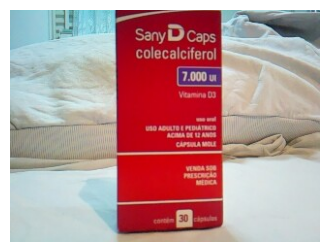

In [44]:
img_path = 'dataset/sany_d/image_20251018-080127.jpg'
image_classification(img_path, model_path, labels, top_k_results=len(labels))

In [45]:
def capture_image(image_path):
    
  picam2 = Picamera2() 
  
  config = picam2.create_still_configuration(main={"size": (224, 224)})
  picam2.configure(config)
  picam2.start()

  time.sleep(8)
  
  picam2.capture_file(image_path)
  print("Image captured: "+image_path)

  picam2.stop()
  picam2.close()

[3:00:41.554893137] [12437]  INFO Camera camera_manager.cpp:326 libcamera v0.5.1+100-e53bdf1f
[3:00:41.648087729] [12447]  WARN RPiSdn sdn.cpp:40 Using legacy SDN tuning - please consider moving SDN inside rpi.denoise
[3:00:41.653387890] [12447]  INFO RPI vc4.cpp:440 Registered camera /base/soc/i2c0mux/i2c@1/ov5647@36 to Unicam device /dev/media3 and ISP device /dev/media0
[3:00:41.653497941] [12447]  INFO RPI pipeline_base.cpp:1107 Using configuration file '/usr/share/libcamera/pipeline/rpi/vc4/rpi_apps.yaml'
[3:00:41.677373719] [12437]  INFO Camera camera.cpp:1205 configuring streams: (0) 224x224-BGR888/sRGB (1) 640x480-SGBRG10_CSI2P/RAW
[3:00:41.678150431] [12447]  INFO RPI vc4.cpp:615 Sensor: /base/soc/i2c0mux/i2c@1/ov5647@36 - Selected sensor format: 640x480-SGBRG10_1X10 - Selected unicam format: 640x480-pGAA


Image captured: images/img_path_camera.jpg

[PREDICTION]        [Prob]

cloridrato_de_ambroxol: 99.3%
sany_d              : 0.5%
cefalexina          : 0.2%
background          : 0.0%

	Inference time: 36.3ms


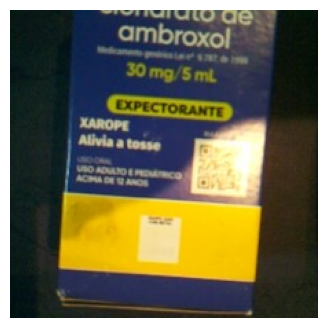

In [47]:
img_path_camera = 'images/img_path_camera.jpg'
capture_image(img_path_camera)
image_classification(img_path_camera, model_path, labels, top_k_results=len(labels))